In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import folium

# -----------------------------
# Setup
# -----------------------------
Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load clean features
# -----------------------------
feature_df = pd.read_parquet("data/processed/features_clean.parquet").copy()

required_cols = [
    "parcel_id",
    "parcel_area_acres",
    "intersects_waterbody",
    "centroid_lat",
    "centroid_lon",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "acreage_score",
    "water_score",
    "flowline_score",
    "water_intersection_penalty",
    "baseline_score_v2"
]

missing = [c for c in required_cols if c not in feature_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

feature_df = feature_df[required_cols].dropna().copy()
feature_df["parcel_id"] = feature_df["parcel_id"].astype(str)

# -----------------------------
# Monte Carlo simulation
# -----------------------------
n_simulations = 1000
top_k = 20
rng = np.random.default_rng(42)

score_matrix = np.zeros((len(feature_df), n_simulations), dtype=np.float32)
topk_counts = np.zeros(len(feature_df), dtype=np.int32)
rank_sum = np.zeros(len(feature_df), dtype=np.float64)

for i in range(n_simulations):
    positive_weights = rng.dirichlet([2.0, 2.0, 2.0])  # acreage, water, flowline
    penalty_weight = rng.uniform(0.15, 0.35)

    sim_score = (
        positive_weights[0] * feature_df["acreage_score"].values +
        positive_weights[1] * feature_df["water_score"].values +
        positive_weights[2] * feature_df["flowline_score"].values -
        penalty_weight * feature_df["water_intersection_penalty"].values
    )

    score_matrix[:, i] = sim_score

    order = np.argsort(-sim_score)  # descending
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(sim_score) + 1)

    rank_sum += ranks
    topk_counts += (ranks <= top_k).astype(np.int32)

feature_df["mc_mean_score"] = score_matrix.mean(axis=1)
feature_df["mc_score_std"] = score_matrix.std(axis=1)
feature_df["p_top20"] = topk_counts / n_simulations
feature_df["avg_rank"] = rank_sum / n_simulations
feature_df["robust_rank"] = feature_df["avg_rank"].rank(method="dense").astype(int)

# Confidence score
# higher p_top20 is better
# lower std is better
# no water intersection is better
std_scaled = feature_df["mc_score_std"]
std_scaled = (std_scaled - std_scaled.min()) / (std_scaled.max() - std_scaled.min() + 1e-9)

feature_df["confidence_score"] = (
    0.6 * feature_df["p_top20"] +
    0.3 * (1 - std_scaled) +
    0.1 * (1 - feature_df["water_intersection_penalty"])
)

# -----------------------------
# Save robustness outputs
# -----------------------------
robustness_cols = [
    "parcel_id",
    "parcel_area_acres",
    "intersects_waterbody",
    "centroid_lat",
    "centroid_lon",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "baseline_score_v2",
    "mc_mean_score",
    "mc_score_std",
    "p_top20",
    "avg_rank",
    "robust_rank",
    "confidence_score"
]

robustness_df = feature_df[robustness_cols].copy()
robustness_df = robustness_df.sort_values(["robust_rank", "p_top20", "mc_mean_score"], ascending=[True, False, False])

robustness_df.to_csv("outputs/robustness.csv", index=False)

top20_robust = robustness_df.head(20).copy()
top20_robust.to_csv("outputs/top20_robust.csv", index=False)

# -----------------------------
# Charts
# -----------------------------
# 1. Top 20 robust parcels
plt.figure(figsize=(12, 6))
plot_df = top20_robust.sort_values("mc_mean_score", ascending=True)
plt.barh(plot_df["parcel_id"], plot_df["mc_mean_score"])
plt.xlabel("Monte Carlo Mean Score")
plt.ylabel("Parcel ID")
plt.title("Top 20 Robust Parcels by Monte Carlo Mean Score")
plt.tight_layout()
plt.savefig("outputs/charts/top20_robust_bar.png", dpi=150)
plt.close()

# 2. Score stability histogram
plt.figure(figsize=(10, 6))
plt.hist(robustness_df["mc_score_std"], bins=30)
plt.xlabel("Monte Carlo Score Std")
plt.ylabel("Number of Parcels")
plt.title("Distribution of Score Stability")
plt.tight_layout()
plt.savefig("outputs/charts/score_stability_hist.png", dpi=150)
plt.close()

# 3. Confidence vs average rank
plt.figure(figsize=(10, 6))
plt.scatter(robustness_df["avg_rank"], robustness_df["confidence_score"], s=8, alpha=0.5)
plt.xlabel("Average Rank")
plt.ylabel("Confidence Score")
plt.title("Confidence vs Average Rank")
plt.tight_layout()
plt.savefig("outputs/charts/confidence_vs_rank.png", dpi=150)
plt.close()

# -----------------------------
# Map
# -----------------------------
map_center = [robustness_df["centroid_lat"].median(), robustness_df["centroid_lon"].median()]
m = folium.Map(location=map_center, zoom_start=10, tiles="OpenStreetMap")

for _, row in top20_robust.iterrows():
    popup_text = (
        f"Parcel ID: {row['parcel_id']}<br>"
        f"Robust Rank: {int(row['robust_rank'])}<br>"
        f"Area (acres): {row['parcel_area_acres']:.2f}<br>"
        f"Water Dist (km): {row['dist_to_waterbody_km']:.3f}<br>"
        f"Flowline Dist (km): {row['dist_to_flowline_km']:.3f}<br>"
        f"Top20 Probability: {row['p_top20']:.3f}<br>"
        f"Confidence: {row['confidence_score']:.3f}<br>"
        f"Intersects Waterbody: {int(row['intersects_waterbody'])}"
    )

    folium.CircleMarker(
        location=[row["centroid_lat"], row["centroid_lon"]],
        radius=5,
        popup=popup_text,
        fill=True
    ).add_to(m)

m.save("outputs/map_robust_top20.html")

# -----------------------------
# Final summary files
# -----------------------------
summary_df = top20_robust[[
    "parcel_id",
    "robust_rank",
    "parcel_area_acres",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "intersects_waterbody",
    "p_top20",
    "mc_mean_score",
    "mc_score_std",
    "confidence_score"
]].copy()

summary_df.to_csv("outputs/final_shortlist_summary.csv", index=False)

# -----------------------------
# Display preview
# -----------------------------
display(top20_robust.head(20))
print("Saved:")
print("- outputs/robustness.csv")
print("- outputs/top20_robust.csv")
print("- outputs/final_shortlist_summary.csv")
print("- outputs/map_robust_top20.html")
print("- outputs/charts/top20_robust_bar.png")
print("- outputs/charts/score_stability_hist.png")
print("- outputs/charts/confidence_vs_rank.png")

,parcel_id,parcel_area_acres,intersects_waterbody,centroid_lat,centroid_lon,dist_to_waterbody_km,dist_to_flowline_km,baseline_score_v2,mc_mean_score,mc_score_std,p_top20,avg_rank,robust_rank,confidence_score
302780,804168,118.403491,0,30.345479,-97.987155,0.015537,0.012437,0.462690,0.678289,0.174047,0.399,41.004,1,0.362117
82039,214268,75.151995,0,30.310361,-97.525505,0.036756,0.054085,0.457231,0.673614,0.175629,0.241,99.965,2,0.264796
243589,522658,155.160088,0,30.376648,-97.863202,0.011801,0.102746,0.466037,0.679607,0.171976,0.383,101.023,3,0.355817
319567,858777,7.078420,0,30.457331,-97.585634,0.000000,0.009550,0.450699,0.669603,0.179023,0.244,233.272,4,0.261188
279780,718163,5.096464,0,30.338292,-97.995035,0.001584,0.010369,0.450449,0.669399,0.179098,0.228,260.442,5,0.251468
318783,857647,15.908806,0,30.439095,-97.520808,0.051800,0.018165,0.450764,0.669236,0.178351,0.000,274.654,6,0.115859
129078,278089,9.976370,0,30.458601,-97.570816,0.056037,0.005025,0.450153,0.668931,0.178661,0.000,339.511,7,0.115364
82040,214269,2.588645,0,30.307169,-97.530173,0.015477,0.014270,0.449915,0.668875,0.179124,0.074,341.818,8,0.159027
57462,178407,3.105145,0,30.469019,-97.938702,0.030512,0.007264,0.449789,0.668784,0.179069,0.000,343.583,9,0.114715
144115,298895,2.976512,0,30.146765,-97.669152,0.035339,0.002764,0.449735,0.668774,0.179076,0.006,353.100,10,0.118304


Saved:
- outputs/robustness.csv
- outputs/top20_robust.csv
- outputs/final_shortlist_summary.csv
- outputs/map_robust_top20.html
- outputs/charts/top20_robust_bar.png
- outputs/charts/score_stability_hist.png
- outputs/charts/confidence_vs_rank.png


In [2]:
import pandas as pd
from IPython.display import Image, display

robustness = pd.read_csv("outputs/robustness.csv")
top20 = pd.read_csv("outputs/top20_robust.csv")
summary = pd.read_csv("outputs/final_shortlist_summary.csv")

display(top20.head(20))
display(summary.head(20))

print("Robustness shape:", robustness.shape)
print("Top20 shape:", top20.shape)
print("Summary shape:", summary.shape)

,parcel_id,parcel_area_acres,intersects_waterbody,centroid_lat,centroid_lon,dist_to_waterbody_km,dist_to_flowline_km,baseline_score_v2,mc_mean_score,mc_score_std,p_top20,avg_rank,robust_rank,confidence_score
0,804168,118.403491,0,30.345479,-97.987155,0.015537,0.012437,0.462690,0.678289,0.174047,0.399,41.004,1,0.362117
1,214268,75.151995,0,30.310361,-97.525505,0.036756,0.054085,0.457231,0.673614,0.175629,0.241,99.965,2,0.264796
2,522658,155.160088,0,30.376648,-97.863202,0.011801,0.102746,0.466037,0.679607,0.171976,0.383,101.023,3,0.355817
3,858777,7.078420,0,30.457331,-97.585634,0.000000,0.009550,0.450699,0.669603,0.179023,0.244,233.272,4,0.261188
4,718163,5.096464,0,30.338292,-97.995035,0.001584,0.010369,0.450449,0.669399,0.179098,0.228,260.442,5,0.251468
5,857647,15.908806,0,30.439095,-97.520808,0.051800,0.018165,0.450764,0.669236,0.178351,0.000,274.654,6,0.115859
6,278089,9.976370,0,30.458601,-97.570816,0.056037,0.005025,0.450153,0.668931,0.178661,0.000,339.511,7,0.115364
7,214269,2.588645,0,30.307169,-97.530173,0.015477,0.014270,0.449915,0.668875,0.179124,0.074,341.818,8,0.159027
8,178407,3.105145,0,30.469019,-97.938702,0.030512,0.007264,0.449789,0.668785,0.179069,0.000,343.583,9,0.114715
9,298895,2.976512,0,30.146765,-97.669152,0.035339,0.002764,0.449735,0.668774,0.179076,0.006,353.100,10,0.118304


,parcel_id,robust_rank,parcel_area_acres,dist_to_waterbody_km,dist_to_flowline_km,intersects_waterbody,p_top20,mc_mean_score,mc_score_std,confidence_score
0,804168,1,118.403491,0.015537,0.012437,0,0.399,0.678289,0.174047,0.362117
1,214268,2,75.151995,0.036756,0.054085,0,0.241,0.673614,0.175629,0.264796
2,522658,3,155.160088,0.011801,0.102746,0,0.383,0.679607,0.171976,0.355817
3,858777,4,7.078420,0.000000,0.009550,0,0.244,0.669603,0.179023,0.261188
4,718163,5,5.096464,0.001584,0.010369,0,0.228,0.669399,0.179098,0.251468
5,857647,6,15.908806,0.051800,0.018165,0,0.000,0.669236,0.178351,0.115859
6,278089,7,9.976370,0.056037,0.005025,0,0.000,0.668931,0.178661,0.115364
7,214269,8,2.588645,0.015477,0.014270,0,0.074,0.668875,0.179124,0.159027
8,178407,9,3.105145,0.030512,0.007264,0,0.000,0.668785,0.179069,0.114715
9,298895,10,2.976512,0.035339,0.002764,0,0.006,0.668774,0.179076,0.118304


Robustness shape: (372533, 14)
Top20 shape: (20, 14)
Summary shape: (20, 10)


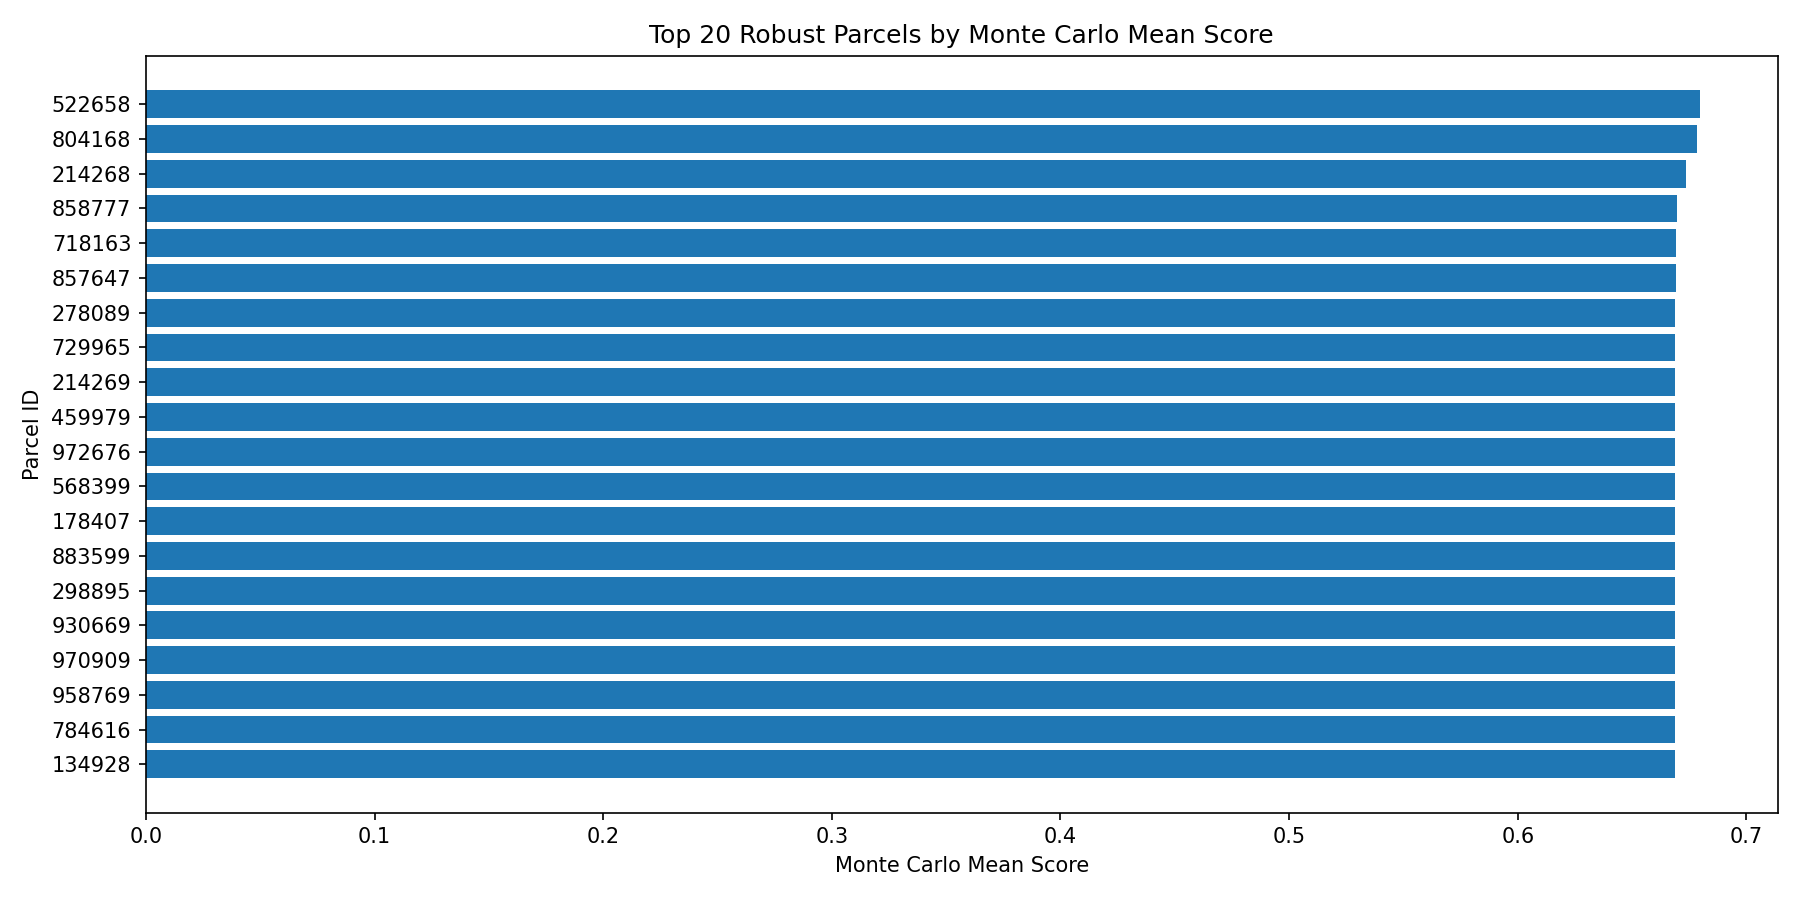

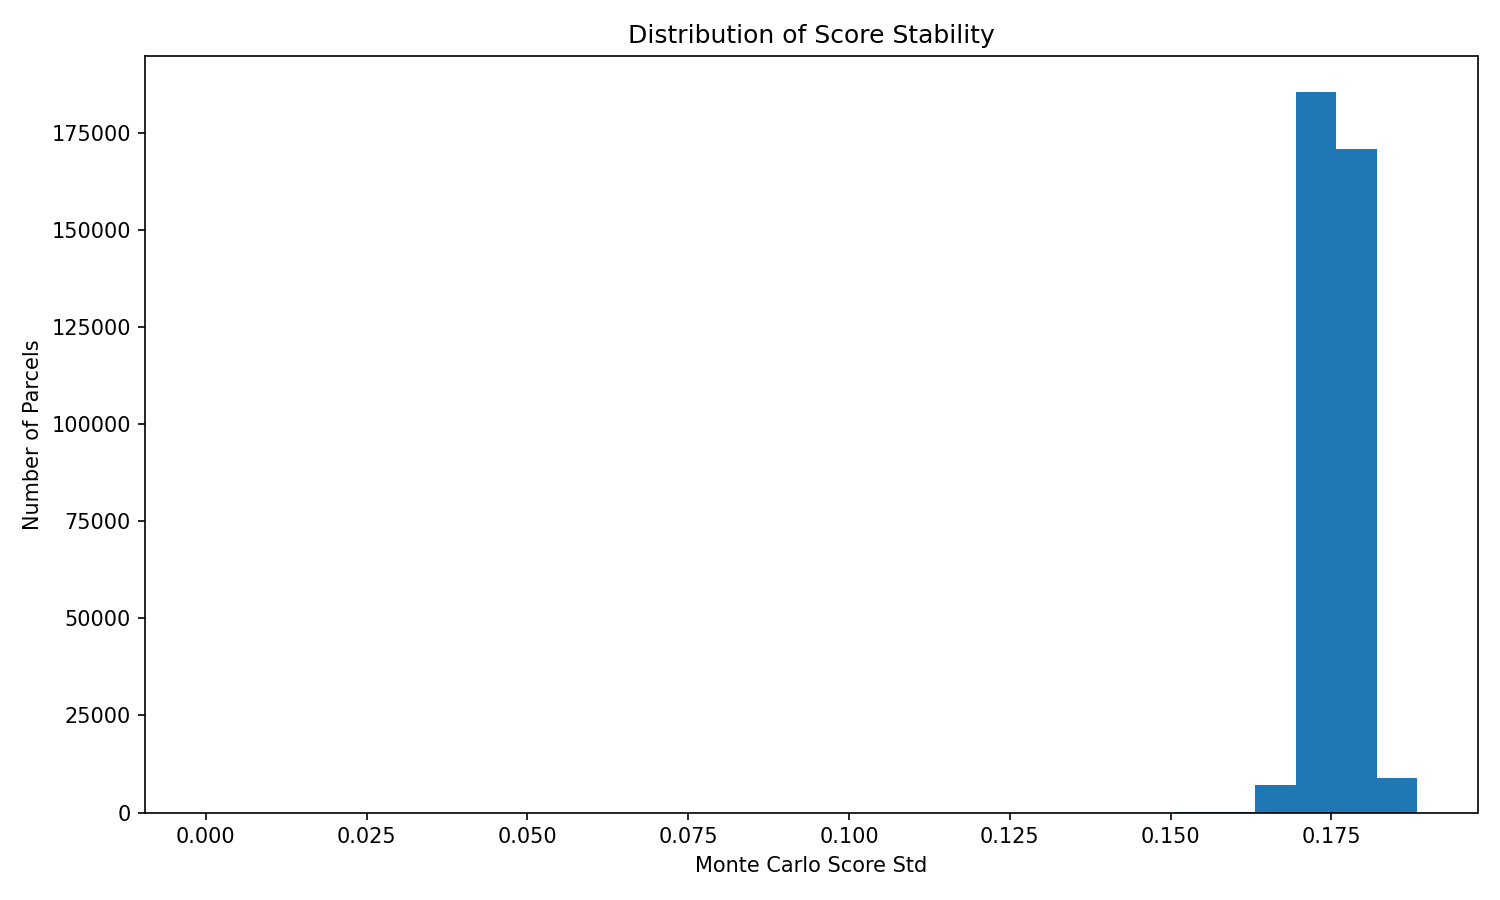

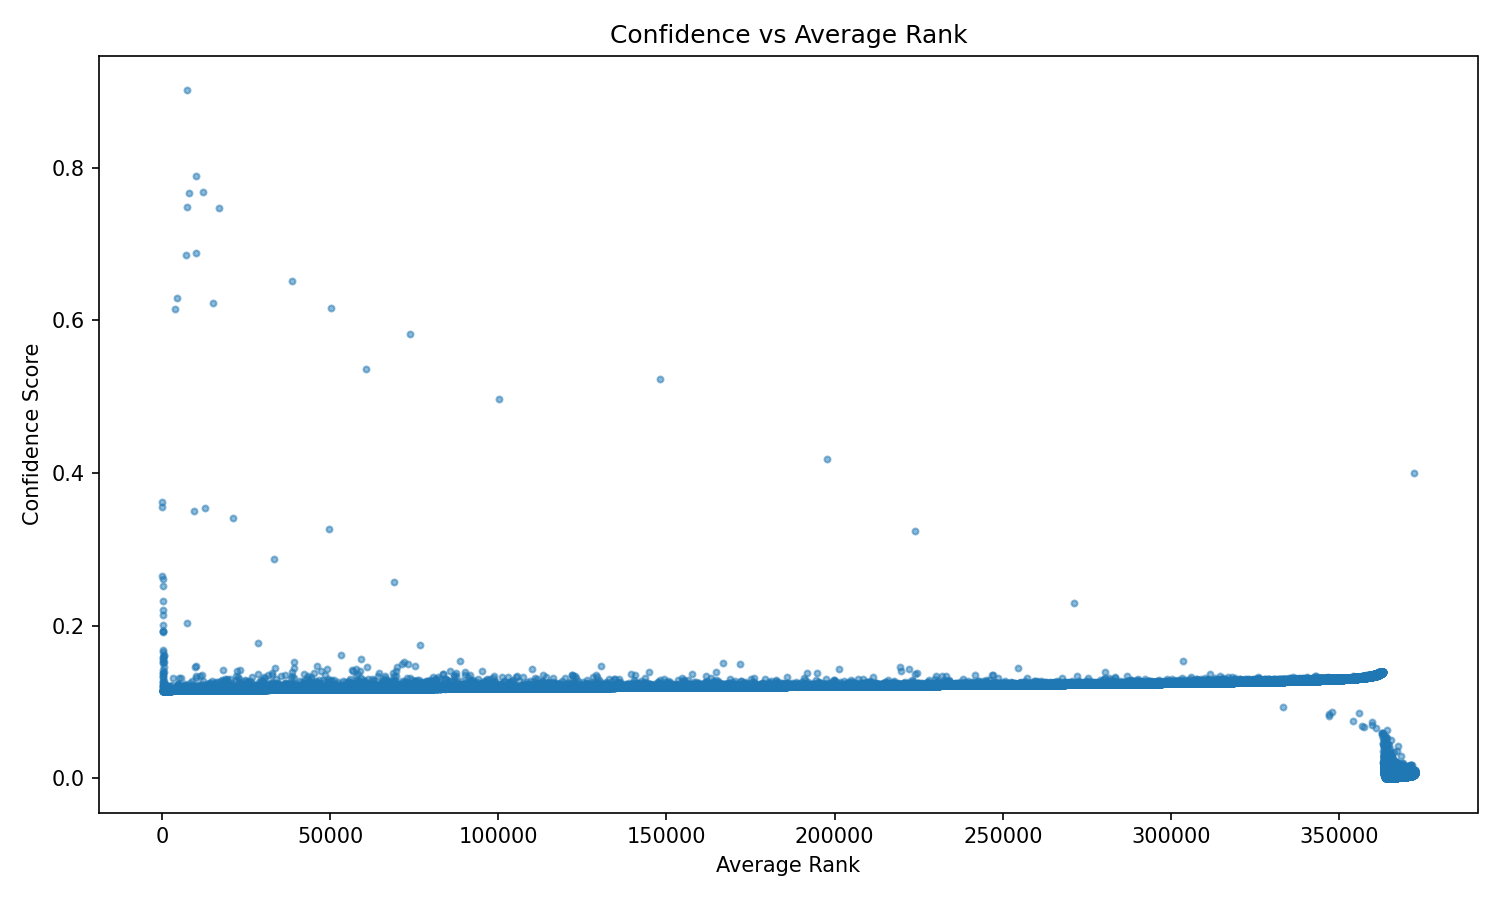

In [3]:
display(Image(filename="outputs/charts/top20_robust_bar.png"))
display(Image(filename="outputs/charts/score_stability_hist.png"))
display(Image(filename="outputs/charts/confidence_vs_rank.png"))

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

feature_df = pd.read_parquet("data/processed/features_clean.parquet").copy()

# Hard filters
MIN_ACRES = 50
MAX_WATERBODY_KM = 5
MAX_FLOWLINE_KM = 2

filtered_df = feature_df[
    (feature_df["parcel_area_acres"] >= MIN_ACRES) &
    (feature_df["intersects_waterbody"] == 0) &
    (feature_df["dist_to_waterbody_km"] <= MAX_WATERBODY_KM) &
    (feature_df["dist_to_flowline_km"] <= MAX_FLOWLINE_KM)
].copy()

filtered_df = filtered_df.dropna().copy()

print("Original rows:", len(feature_df))
print("Filtered rows:", len(filtered_df))
print("Unique parcels after filter:", filtered_df["parcel_id"].nunique())
filtered_df.head()

Original rows: 372533
Filtered rows: 630
Unique parcels after filter: 630


,parcel_id,parcel_area_acres,intersects_waterbody,centroid_lat,centroid_lon,dist_to_waterbody_km,dist_to_flowline_km,acreage_score,water_score,flowline_score,water_intersection_penalty,baseline_score_v2
667,100838,62.595525,0,30.253379,-97.751052,0.466373,0.305754,0.015325,0.974926,0.982802,0.0,0.446795
1237,101541,54.439945,0,30.249588,-97.903690,0.487958,0.342202,0.013329,0.973766,0.980752,0.0,0.445240
2202,102984,86.278276,0,30.268240,-97.843843,0.519471,0.245337,0.021124,0.972071,0.986200,0.0,0.449057
2204,102991,89.799686,0,30.264068,-97.894544,0.435420,0.153377,0.021986,0.976590,0.991373,0.0,0.451577
2209,103009,129.794304,0,30.270069,-97.915837,0.981073,0.233560,0.031778,0.947254,0.986863,0.0,0.446506


In [5]:
def minmax_scale(series):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

filtered_df["acreage_score"] = minmax_scale(filtered_df["parcel_area_acres"])
filtered_df["water_score"] = 1 - minmax_scale(filtered_df["dist_to_waterbody_km"])
filtered_df["flowline_score"] = 1 - minmax_scale(filtered_df["dist_to_flowline_km"])
filtered_df["water_intersection_penalty"] = filtered_df["intersects_waterbody"].astype(float)

filtered_df["baseline_score_v3"] = (
    0.50 * filtered_df["acreage_score"] +
    0.30 * filtered_df["water_score"] +
    0.20 * filtered_df["flowline_score"] -
    0.25 * filtered_df["water_intersection_penalty"]
)

top20_filtered = filtered_df.sort_values("baseline_score_v3", ascending=False).head(20).copy()

print("Filtered Top 20 Preview")
display(top20_filtered[[
    "parcel_id",
    "parcel_area_acres",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "baseline_score_v3"
]].head(20))

Filtered Top 20 Preview


,parcel_id,parcel_area_acres,dist_to_waterbody_km,dist_to_flowline_km,baseline_score_v3
185856,354620,2849.044222,1.708720,0.266853,0.773817
361622,963956,1565.332287,1.425914,0.103532,0.599126
185201,353730,1258.261626,1.147585,0.072734,0.579539
348636,934035,1362.761849,1.467550,0.007079,0.572048
17482,123209,1041.238555,1.041589,0.001349,0.562691
186406,355294,1373.693797,1.358185,0.421356,0.527176
302780,804168,118.403491,0.015537,0.012437,0.510111
259831,564023,666.371224,0.711554,0.168397,0.508573
243589,522658,155.160088,0.011801,0.102746,0.504238
332682,893807,738.547967,0.825502,0.210937,0.502769


In [6]:
n_simulations = 1000
top_k = 20
rng = np.random.default_rng(42)

score_matrix = np.zeros((len(filtered_df), n_simulations), dtype=np.float32)
topk_counts = np.zeros(len(filtered_df), dtype=np.int32)
rank_sum = np.zeros(len(filtered_df), dtype=np.float64)

for i in range(n_simulations):
    positive_weights = rng.dirichlet([2.0, 2.0, 2.0])  # acreage, water, flowline
    penalty_weight = rng.uniform(0.15, 0.35)

    sim_score = (
        positive_weights[0] * filtered_df["acreage_score"].values +
        positive_weights[1] * filtered_df["water_score"].values +
        positive_weights[2] * filtered_df["flowline_score"].values -
        penalty_weight * filtered_df["water_intersection_penalty"].values
    )

    score_matrix[:, i] = sim_score

    order = np.argsort(-sim_score)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(sim_score) + 1)

    rank_sum += ranks
    topk_counts += (ranks <= top_k).astype(np.int32)

filtered_df["mc_mean_score_v2"] = score_matrix.mean(axis=1)
filtered_df["mc_score_std_v2"] = score_matrix.std(axis=1)
filtered_df["p_top20_v2"] = topk_counts / n_simulations
filtered_df["avg_rank_v2"] = rank_sum / n_simulations
filtered_df["robust_rank_v2"] = filtered_df["avg_rank_v2"].rank(method="dense").astype(int)

std_scaled = filtered_df["mc_score_std_v2"]
std_scaled = (std_scaled - std_scaled.min()) / (std_scaled.max() - std_scaled.min() + 1e-9)

filtered_df["confidence_score_v2"] = (
    0.6 * filtered_df["p_top20_v2"] +
    0.3 * (1 - std_scaled) +
    0.1 * (1 - filtered_df["water_intersection_penalty"])
)

top20_robust_v2 = filtered_df.sort_values(
    ["robust_rank_v2", "p_top20_v2", "mc_mean_score_v2"],
    ascending=[True, False, False]
).head(20).copy()

display(top20_robust_v2[[
    "parcel_id",
    "parcel_area_acres",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "p_top20_v2",
    "mc_mean_score_v2",
    "confidence_score_v2",
    "robust_rank_v2"
]].head(20))

,parcel_id,parcel_area_acres,dist_to_waterbody_km,dist_to_flowline_km,p_top20_v2,mc_mean_score_v2,confidence_score_v2,robust_rank_v2
302780,804168,118.403491,0.015537,0.012437,0.934,0.673966,0.660400,1
162315,324445,83.520968,0.167704,0.001728,0.883,0.653878,0.633483,2
65870,190649,117.748577,0.158879,0.030846,0.889,0.651963,0.645930,3
312391,838573,66.032040,0.172283,0.011115,0.833,0.648985,0.602790,4
82039,214268,75.151995,0.036756,0.054085,0.809,0.656204,0.586778,5
329271,883689,55.181720,0.190680,0.003037,0.795,0.647411,0.578336,6
243589,522658,155.160088,0.011801,0.102746,0.771,0.656944,0.580049,7
241499,513121,90.119131,0.168531,0.042890,0.754,0.644611,0.563511,8
219182,464416,72.877759,0.222987,0.015402,0.714,0.642576,0.536264,9
74034,201906,67.144858,0.150667,0.047031,0.670,0.643074,0.509275,10


In [7]:
from sklearn.cluster import KMeans

cluster_input = filtered_df[["centroid_lat", "centroid_lon"]].copy()

n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
filtered_df["location_cluster"] = kmeans.fit_predict(cluster_input)

cluster_stats = (
    filtered_df.groupby("location_cluster")
    .agg(
        cluster_size=("parcel_id", "count"),
        cluster_avg_area=("parcel_area_acres", "mean"),
        cluster_avg_water_dist=("dist_to_waterbody_km", "mean"),
        cluster_avg_flow_dist=("dist_to_flowline_km", "mean")
    )
    .reset_index()
)

filtered_df = filtered_df.merge(cluster_stats, on="location_cluster", how="left")

display(filtered_df[[
    "parcel_id",
    "location_cluster",
    "cluster_size",
    "cluster_avg_area",
    "cluster_avg_water_dist",
    "cluster_avg_flow_dist"
]].head())

,parcel_id,location_cluster,cluster_size,cluster_avg_area,cluster_avg_water_dist,cluster_avg_flow_dist
0,100838,9,23,78.199258,0.559142,0.248410
1,101541,4,24,79.942743,0.633244,0.230817
2,102984,4,24,79.942743,0.633244,0.230817
3,102991,4,24,79.942743,0.633244,0.230817
4,103009,8,43,156.412610,0.772326,0.151771


In [9]:
import matplotlib.pyplot as plt
import folium
from pathlib import Path

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

filtered_df.to_parquet("data/processed/features_filtered_v2.parquet", index=False)
filtered_df.to_csv("data/processed/features_filtered_v2.csv", index=False)
top20_filtered.to_csv("outputs/top20_filtered_baseline_v3.csv", index=False)
top20_robust_v2.to_csv("outputs/top20_robust_v2.csv", index=False)

robustness_cols = [
    "parcel_id",
    "parcel_area_acres",
    "centroid_lat",
    "centroid_lon",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "baseline_score_v3",
    "mc_mean_score_v2",
    "mc_score_std_v2",
    "p_top20_v2",
    "avg_rank_v2",
    "robust_rank_v2",
    "confidence_score_v2",
]

if "location_cluster" in filtered_df.columns:
    robustness_cols.append("location_cluster")

robustness_v2 = filtered_df[robustness_cols].copy()
robustness_v2.to_csv("outputs/robustness_v2.csv", index=False)

plt.figure(figsize=(12, 6))
plot_df = top20_robust_v2.sort_values("mc_mean_score_v2", ascending=True)
plt.barh(plot_df["parcel_id"], plot_df["mc_mean_score_v2"])
plt.xlabel("Monte Carlo Mean Score")
plt.ylabel("Parcel ID")
plt.title("Top 20 Robust Parcels After Hard Filtering")
plt.tight_layout()
plt.savefig("outputs/charts/top20_robust_v2_bar.png", dpi=150)
plt.close()

plt.figure(figsize=(10, 6))
plt.hist(filtered_df["mc_score_std_v2"], bins=30)
plt.xlabel("Monte Carlo Score Std")
plt.ylabel("Number of Parcels")
plt.title("Score Stability After Hard Filtering")
plt.tight_layout()
plt.savefig("outputs/charts/score_stability_v2_hist.png", dpi=150)
plt.close()

plt.figure(figsize=(10, 6))
plt.scatter(filtered_df["avg_rank_v2"], filtered_df["confidence_score_v2"], s=8, alpha=0.5)
plt.xlabel("Average Rank")
plt.ylabel("Confidence Score")
plt.title("Confidence vs Average Rank After Hard Filtering")
plt.tight_layout()
plt.savefig("outputs/charts/confidence_vs_rank_v2.png", dpi=150)
plt.close()

map_center = [filtered_df["centroid_lat"].median(), filtered_df["centroid_lon"].median()]
m = folium.Map(location=map_center, zoom_start=10, tiles="OpenStreetMap")

for _, row in top20_robust_v2.iterrows():
    popup_text = (
        f"Parcel ID: {row['parcel_id']}<br>"
        f"Robust Rank: {int(row['robust_rank_v2'])}<br>"
        f"Area (acres): {row['parcel_area_acres']:.2f}<br>"
        f"Water Dist (km): {row['dist_to_waterbody_km']:.3f}<br>"
        f"Flowline Dist (km): {row['dist_to_flowline_km']:.3f}<br>"
        f"Top20 Probability: {row['p_top20_v2']:.3f}<br>"
        f"Confidence: {row['confidence_score_v2']:.3f}"
    )
    if "location_cluster" in row.index:
        popup_text += f"<br>Cluster: {row['location_cluster']}"

    folium.CircleMarker(
        location=[row["centroid_lat"], row["centroid_lon"]],
        radius=5,
        popup=popup_text,
        fill=True
    ).add_to(m)

m.save("outputs/map_robust_top20_v2.html")

display(top20_robust_v2.head(20))

,parcel_id,parcel_area_acres,intersects_waterbody,centroid_lat,centroid_lon,dist_to_waterbody_km,dist_to_flowline_km,acreage_score,water_score,flowline_score,water_intersection_penalty,baseline_score_v2,baseline_score_v3,mc_mean_score_v2,mc_score_std_v2,p_top20_v2,avg_rank_v2,robust_rank_v2,confidence_score_v2
302780,804168,118.403491,0,30.345479,-97.987155,0.015537,0.012437,0.024436,0.998618,0.991535,0.0,0.462690,0.510111,0.673966,0.174093,0.934,6.249,1,0.660400
162315,324445,83.520968,0,30.209457,-97.930112,0.167704,0.001728,0.011974,0.942339,0.999155,0.0,0.456482,0.488520,0.653878,0.172429,0.883,10.853,2,0.633483
65870,190649,117.748577,0,30.242763,-97.533531,0.158879,0.030846,0.024202,0.945603,0.978435,0.0,0.460150,0.491469,0.651963,0.168432,0.889,11.557,3,0.645930
312391,838573,66.032040,0,30.265175,-97.559221,0.172283,0.011115,0.005726,0.940646,0.992475,0.0,0.454403,0.483552,0.648985,0.172742,0.833,14.544,4,0.602790
82039,214268,75.151995,0,30.310361,-97.525505,0.036756,0.054085,0.008984,0.990770,0.961898,0.0,0.457231,0.494103,0.656204,0.173470,0.809,14.810,5,0.586778
329271,883689,55.181720,0,30.121840,-97.704259,0.190680,0.003037,0.001849,0.933841,0.998224,0.0,0.452979,0.480722,0.647411,0.173489,0.795,16.536,6,0.578336
243589,522658,155.160088,0,30.376648,-97.863202,0.011801,0.102746,0.037568,1.000000,0.927271,0.0,0.466037,0.504238,0.656944,0.166209,0.771,17.656,7,0.580049
241499,513121,90.119131,0,30.172597,-97.763665,0.168531,0.042890,0.014331,0.942033,0.969864,0.0,0.456849,0.483748,0.644611,0.169073,0.754,18.130,8,0.563511
219182,464416,72.877759,0,30.129136,-97.588782,0.222987,0.015402,0.008171,0.921893,0.989425,0.0,0.454303,0.478538,0.642576,0.170540,0.714,19.136,9,0.536264
74034,201906,67.144858,0,30.287659,-97.485614,0.150667,0.047031,0.006123,0.948640,0.966918,0.0,0.454571,0.481037,0.643074,0.170806,0.670,21.933,10,0.509275


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

filtered_df = pd.read_parquet("data/processed/features_filtered_v2.parquet").copy()

def minmax_scale(series):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

# Recompute normalized scores just to be safe
filtered_df["acreage_score"] = minmax_scale(filtered_df["parcel_area_acres"])
filtered_df["water_score"] = 1 - minmax_scale(filtered_df["dist_to_waterbody_km"])
filtered_df["flowline_score"] = 1 - minmax_scale(filtered_df["dist_to_flowline_km"])
filtered_df["water_intersection_penalty"] = filtered_df["intersects_waterbody"].astype(float)

# Flood-risk proxy:
# Near waterbody + near flowline + direct waterbody intersection => higher risk
water_risk_component = 1 - filtered_df["water_score"]       # closer to waterbody => higher risk
flow_risk_component = 1 - filtered_df["flowline_score"]     # closer to flowline => higher risk

filtered_df["flood_proxy_score"] = (
    0.45 * water_risk_component +
    0.35 * flow_risk_component +
    0.20 * filtered_df["water_intersection_penalty"]
)

filtered_df["flood_proxy_score"] = minmax_scale(filtered_df["flood_proxy_score"])

# Binary high-risk proxy if needed
filtered_df["flood_proxy_penalty"] = (filtered_df["flood_proxy_score"] >= 0.70).astype(float)

# New score with flood proxy
filtered_df["baseline_score_v4"] = (
    0.45 * filtered_df["acreage_score"] +
    0.22 * filtered_df["water_score"] +
    0.13 * filtered_df["flowline_score"] -
    0.10 * filtered_df["water_intersection_penalty"] -
    0.10 * filtered_df["flood_proxy_score"]
)

top20_v4 = filtered_df.sort_values("baseline_score_v4", ascending=False).head(20).copy()

# Monte Carlo with flood proxy
n_simulations = 1000
top_k = 20
rng = np.random.default_rng(42)

score_matrix = np.zeros((len(filtered_df), n_simulations), dtype=np.float32)
topk_counts = np.zeros(len(filtered_df), dtype=np.int32)
rank_sum = np.zeros(len(filtered_df), dtype=np.float64)

for i in range(n_simulations):
    pos_w = rng.dirichlet([2.0, 2.0, 2.0])   # acreage, water, flowline
    water_penalty_w = rng.uniform(0.08, 0.20)
    flood_proxy_w = rng.uniform(0.05, 0.15)

    sim_score = (
        pos_w[0] * filtered_df["acreage_score"].values +
        pos_w[1] * filtered_df["water_score"].values +
        pos_w[2] * filtered_df["flowline_score"].values -
        water_penalty_w * filtered_df["water_intersection_penalty"].values -
        flood_proxy_w * filtered_df["flood_proxy_score"].values
    )

    score_matrix[:, i] = sim_score
    order = np.argsort(-sim_score)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(sim_score) + 1)
    rank_sum += ranks
    topk_counts += (ranks <= top_k).astype(np.int32)

filtered_df["mc_mean_score_v3"] = score_matrix.mean(axis=1)
filtered_df["mc_score_std_v3"] = score_matrix.std(axis=1)
filtered_df["p_top20_v3"] = topk_counts / n_simulations
filtered_df["avg_rank_v3"] = rank_sum / n_simulations
filtered_df["robust_rank_v3"] = filtered_df["avg_rank_v3"].rank(method="dense").astype(int)

std_scaled = filtered_df["mc_score_std_v3"]
std_scaled = (std_scaled - std_scaled.min()) / (std_scaled.max() - std_scaled.min() + 1e-9)

filtered_df["confidence_score_v3"] = (
    0.55 * filtered_df["p_top20_v3"] +
    0.25 * (1 - std_scaled) +
    0.10 * (1 - filtered_df["water_intersection_penalty"]) +
    0.10 * (1 - filtered_df["flood_proxy_penalty"])
)

top20_robust_v3 = filtered_df.sort_values(
    ["robust_rank_v3", "p_top20_v3", "mc_mean_score_v3"],
    ascending=[True, False, False]
).head(20).copy()

Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

filtered_df.to_parquet("data/processed/features_filtered_v3.parquet", index=False)
filtered_df.to_csv("data/processed/features_filtered_v3.csv", index=False)
top20_v4.to_csv("outputs/top20_baseline_v4.csv", index=False)
top20_robust_v3.to_csv("outputs/top20_robust_v3.csv", index=False)

display(top20_robust_v3[[
    "parcel_id",
    "parcel_area_acres",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "flood_proxy_score",
    "p_top20_v3",
    "confidence_score_v3",
    "robust_rank_v3"
]].head(20))

,parcel_id,parcel_area_acres,dist_to_waterbody_km,dist_to_flowline_km,flood_proxy_score,p_top20_v3,confidence_score_v3,robust_rank_v3
542,804168,118.403491,0.015537,0.012437,0.000000,0.993,0.746150,1
272,324445,83.520968,0.167704,0.001728,0.046394,0.963,0.733005,2
116,214268,75.151995,0.036756,0.054085,0.028470,0.935,0.715342,3
109,190649,117.748577,0.158879,0.030846,0.058236,0.972,0.745488,4
570,838573,66.032040,0.172283,0.011115,0.052742,0.922,0.709832,5
456,522658,155.160088,0.011801,0.102746,0.044781,0.886,0.702099,6
593,883689,55.181720,0.190680,0.003037,0.054891,0.901,0.696897,7
452,513121,90.119131,0.168531,0.042890,0.067667,0.888,0.698034,8
430,464416,72.877759,0.222987,0.015402,0.072207,0.843,0.670615,9
115,201906,67.144858,0.150667,0.047031,0.063691,0.817,0.655648,10


In [12]:
import matplotlib.pyplot as plt
import folium
from pathlib import Path

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

robustness_v3 = filtered_df[[
    "parcel_id",
    "parcel_area_acres",
    "centroid_lat",
    "centroid_lon",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "flood_proxy_score",
    "baseline_score_v4",
    "mc_mean_score_v3",
    "mc_score_std_v3",
    "p_top20_v3",
    "avg_rank_v3",
    "robust_rank_v3",
    "confidence_score_v3"
]].copy()

robustness_v3.to_csv("outputs/robustness_v3.csv", index=False)
top20_robust_v3.to_csv("outputs/top20_robust_v3.csv", index=False)

plt.figure(figsize=(12, 6))
plot_df = top20_robust_v3.sort_values("mc_mean_score_v3", ascending=True)
plt.barh(plot_df["parcel_id"].astype(str), plot_df["mc_mean_score_v3"])
plt.xlabel("Monte Carlo Mean Score")
plt.ylabel("Parcel ID")
plt.title("Top 20 Robust Parcels with Flood Proxy Layer")
plt.tight_layout()
plt.savefig("outputs/charts/top20_robust_v3_bar.png", dpi=150)
plt.close()

plt.figure(figsize=(10, 6))
plt.hist(filtered_df["mc_score_std_v3"], bins=30)
plt.xlabel("Monte Carlo Score Std")
plt.ylabel("Number of Parcels")
plt.title("Score Stability with Flood Proxy Layer")
plt.tight_layout()
plt.savefig("outputs/charts/score_stability_v3_hist.png", dpi=150)
plt.close()

plt.figure(figsize=(10, 6))
plt.scatter(filtered_df["avg_rank_v3"], filtered_df["confidence_score_v3"], s=8, alpha=0.5)
plt.xlabel("Average Rank")
plt.ylabel("Confidence Score")
plt.title("Confidence vs Average Rank with Flood Proxy Layer")
plt.tight_layout()
plt.savefig("outputs/charts/confidence_vs_rank_v3.png", dpi=150)
plt.close()

map_center = [filtered_df["centroid_lat"].median(), filtered_df["centroid_lon"].median()]
m = folium.Map(location=map_center, zoom_start=10, tiles="OpenStreetMap")

for _, row in top20_robust_v3.iterrows():
    popup_text = (
        f"Parcel ID: {row['parcel_id']}<br>"
        f"Robust Rank: {int(row['robust_rank_v3'])}<br>"
        f"Area (acres): {row['parcel_area_acres']:.2f}<br>"
        f"Water Dist (km): {row['dist_to_waterbody_km']:.3f}<br>"
        f"Flowline Dist (km): {row['dist_to_flowline_km']:.3f}<br>"
        f"Flood Proxy Score: {row['flood_proxy_score']:.3f}<br>"
        f"Top20 Probability: {row['p_top20_v3']:.3f}<br>"
        f"Confidence: {row['confidence_score_v3']:.3f}"
    )

    folium.CircleMarker(
        location=[row["centroid_lat"], row["centroid_lon"]],
        radius=5,
        popup=popup_text,
        fill=True
    ).add_to(m)

m.save("outputs/map_robust_top20_v3.html")

display(top20_robust_v3[[
    "parcel_id",
    "robust_rank_v3",
    "parcel_area_acres",
    "dist_to_waterbody_km",
    "dist_to_flowline_km",
    "flood_proxy_score",
    "p_top20_v3",
    "confidence_score_v3"
]].head(20))

,parcel_id,robust_rank_v3,parcel_area_acres,dist_to_waterbody_km,dist_to_flowline_km,flood_proxy_score,p_top20_v3,confidence_score_v3
542,804168,1,118.403491,0.015537,0.012437,0.000000,0.993,0.746150
272,324445,2,83.520968,0.167704,0.001728,0.046394,0.963,0.733005
116,214268,3,75.151995,0.036756,0.054085,0.028470,0.935,0.715342
109,190649,4,117.748577,0.158879,0.030846,0.058236,0.972,0.745488
570,838573,5,66.032040,0.172283,0.011115,0.052742,0.922,0.709832
456,522658,6,155.160088,0.011801,0.102746,0.044781,0.886,0.702099
593,883689,7,55.181720,0.190680,0.003037,0.054891,0.901,0.696897
452,513121,8,90.119131,0.168531,0.042890,0.067667,0.888,0.698034
430,464416,9,72.877759,0.222987,0.015402,0.072207,0.843,0.670615
115,201906,10,67.144858,0.150667,0.047031,0.063691,0.817,0.655648
